In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [16]:
class VanillaAutoencoder(nn.Module):
    """
    Simple fully-connected autoencoder.
    Good for tabular data or flattened images.
    """
    def __init__(self, input_dim: int, latent_dim: int = 32):
        super().__init__()

        # Encoder: compresses input to latent space
        self._encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim),
        )

        # Decoder: reconstructs input from latent space
        self._decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, input_dim),
            nn.Sigmoid(),  # Output in [0, 1] for normalized data
        )

    def forward(self, x):
        z = self._encoder(x)
        x_recon = self._decoder(z)
        return x_recon

    def encode(self, x):
        return self._encoder(x)

    def decode(self, z):
        return self._decoder(z)

In [17]:
def train_vanilla_autoencoder():
    """Example training loop for vanilla autoencoder on MNIST."""
    # Hyperparameters
    input_dim = 28 * 28
    latent_dim = 10
    batch_size = 128
    epochs = 20
    lr = 1e-3

    # Device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Data
    transform = transforms.Compose([
        transforms.ToTensor(),
    ])
    train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    # Model
    model = VanillaAutoencoder(input_dim, latent_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # Training
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for batch_idx, (data, _) in enumerate(train_loader):
            data = data.view(-1, input_dim).to(device)

            optimizer.zero_grad()
            recon = model(data)
            loss = F.mse_loss(recon, data, reduction='sum')
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader.dataset)
        print(f'Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}')

    return model

In [18]:
model = train_vanilla_autoencoder()

Epoch 1/20, Loss: 38.4174
Epoch 2/20, Loss: 19.6859
Epoch 3/20, Loss: 16.5971
Epoch 4/20, Loss: 15.1897
Epoch 5/20, Loss: 14.2581
Epoch 6/20, Loss: 13.5798
Epoch 7/20, Loss: 13.0789
Epoch 8/20, Loss: 12.6899
Epoch 9/20, Loss: 12.3572
Epoch 10/20, Loss: 12.0911
Epoch 11/20, Loss: 11.8542
Epoch 12/20, Loss: 11.6395
Epoch 13/20, Loss: 11.4535
Epoch 14/20, Loss: 11.2974
Epoch 15/20, Loss: 11.1433
Epoch 16/20, Loss: 11.0106
Epoch 17/20, Loss: 10.8899
Epoch 18/20, Loss: 10.7796
Epoch 19/20, Loss: 10.6723
Epoch 20/20, Loss: 10.5781


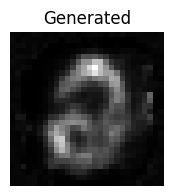

In [19]:
def generate_from_latent(model, latent_vector, device):
    """
    NOTE: THIS WOULD BE SHIT
    Takes a latent vector, runs it through the decoder, and plots the result.
    latent_vector: list or torch.Tensor of shape (latent_dim,)
    """
    model.eval()
    if not isinstance(latent_vector, torch.Tensor):
        latent_vector = torch.tensor(latent_vector, dtype=torch.float32)

    # Add batch dimension and move to device
    z = latent_vector.unsqueeze(0).to(device)

    with torch.no_grad():
        reconstruction = model.decode(z)

    # Reshape to 28x28 for MNIST
    generated_img = reconstruction.view(28, 28).cpu().numpy()

    plt.figure(figsize=(2, 2))
    plt.imshow(generated_img, cmap='gray')
    plt.title("Generated")
    plt.axis('off')
    plt.show()

# Example usage with your 'input' variable
# Since your latent_dim is 10, ensure the input has 10 elements
custom_latent = [0.0] * 10
custom_latent[1] = 1.0 # Tweak a specific dimension

generate_from_latent(model, custom_latent, "cuda" if torch.cuda.is_available() else "cpu")

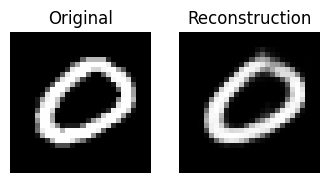

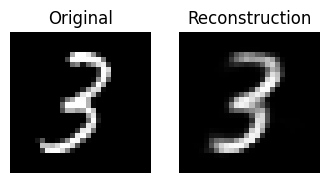

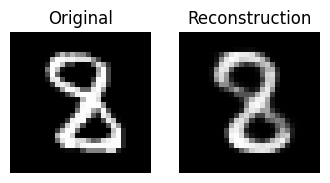

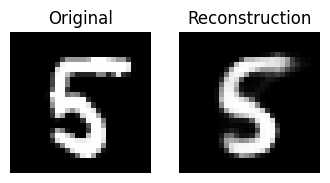

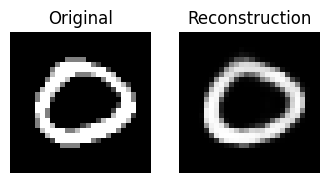

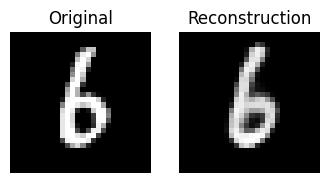

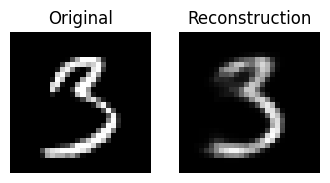

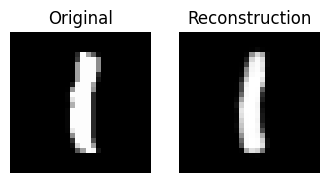

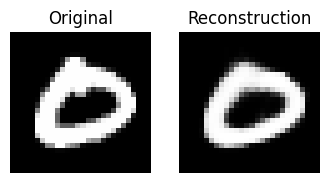

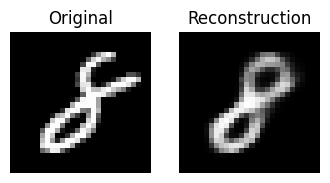

In [21]:
import matplotlib.pyplot as plt
import random

def visualize_reconstruction(model, dataset, device):
    model.eval()
    # Select a random image
    idx = random.randint(0, len(dataset) - 1)
    image, _ = dataset[idx]

    # Prepare image for model
    input_tensor = image.view(-1, 28*28).to(device)

    # Generate reconstruction
    with torch.no_grad():
        reconstruction = model(input_tensor)

    # Reshape for plotting
    original_img = image.squeeze().numpy()
    reconstructed_img = reconstruction.view(28, 28).cpu().numpy()

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(4, 2))
    axes[0].imshow(original_img, cmap='gray')
    axes[0].set_title("Original")
    axes[0].axis('off')

    axes[1].imshow(reconstructed_img, cmap='gray')
    axes[1].set_title("Reconstruction")
    axes[1].axis('off')

    plt.show()

# Call the function
for _ in range(10):
  visualize_reconstruction(model, data, device)

In [9]:
transform = transforms.Compose([
        transforms.ToTensor(),
    ])
device = "cuda" if torch.cuda.is_available() else "cpu"
data = datasets.MNIST('./test-data', train=False, download=True, transform=transform)
test_loader =  DataLoader(data, batch_size=128, shuffle=True)